In [1]:
## 1 — Build vocabulary from rustic_py metadata

import sys
sys.path.insert(0, '..')

from rustic_ml.autoregressive import Vocabulary

vocab = Vocabulary.from_rustic()
print(vocab.summary())

{'title': 'Size', 'field_name': 'size', 'default': 3, 'value': 3, 'min': 0, 'max': None}
Vocabulary  (23 tokens, values_width=12)
  ID  Token                             # params  Fields
--------------------------------------------------------------------------------
   0  <SOS>                                    0  
   1  <EOS>                                    0  
   2  <PAD>                                    0  
   3  <VALUES>                                 0  
   4  NOTE                                     3  note, note_on, note_off
   5  source:sine                             12  frequency, amplitude, attack, decay, … (+8)
   6  source:square                           12  frequency, amplitude, attack, decay, … (+8)
   7  source:saw                              12  frequency, amplitude, attack, decay, … (+8)
   8  source:triangle                         12  frequency, amplitude, attack, decay, … (+8)
   9  source:whitenoise                       11  amplitude, attack, decay, su

In [2]:
## 1.5 — Device detection

import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"CUDA available — {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS (Apple Silicon) available")
else:
    device = torch.device("cpu")
    print("No GPU found — using CPU")

print(f"device = {device}")

CUDA available — AMD Radeon Graphics
device = cuda


/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


In [3]:
## 2 — Random graph generation with filters

from rustic_ml.autoregressive import random_ar_spec, spec_to_sequence
from rustic_ml.data.generation import render_mel
import IPython.display as ipd
import librosa, numpy as np

from rustic_py import GraphSpec

spec = GraphSpec.random(0.1)
print("Spec1:", len(spec.to_spec()["filters"]), "filters")
spec2 = GraphSpec.random(1.0)
print("Spec2:", len(spec2.to_spec()["filters"]), "filters")

spec = spec2.to_spec()
print("Spec filters:", [f["type"] for f in spec["filters"]])
print("Note:", spec["note"], " | Waveforms:", ",".join([f"{spec["source"]["sources"][x]["waveform"]} ({spec["source"]["sources"][x]["frequency_relation"]})" for x in range(len(spec["source"]["sources"]))]))

token_ids, values = spec_to_sequence(spec, vocab)
token_names = [vocab.id_to_token[t] for t in token_ids]
print("\nToken sequence:", token_names)
print("Values matrix shape:", values.shape)

Spec filters: ['HighPassFilter', 'MovingAverage']
Note: 74  | Waveform: whitenoise

Token sequence: ['<SOS>', 'NOTE', '<VALUES>', 'source:whitenoise', '<VALUES>', 'filter:HighPassFilter', '<VALUES>', 'filter:MovingAverage', '<VALUES>', '<EOS>']
Values matrix shape: (10, 12)


In [4]:
## 3 — Round-trip: spec → tokens → spec → render

from rustic_ml.autoregressive import sequence_to_spec
from rustic_py.rustic_py import render

# Encode
token_ids, values = spec_to_sequence(spec, vocab)

# Decode
spec2 = sequence_to_spec(token_ids, values, vocab)

# Verify render doesn't crash
audio = render(spec2)
print("Render OK — audio shape:", audio.shape)

# Compare key fields
print(f"\nOriginal  note={spec['note']}  waveform={spec['source']['waveform']}  "
      f"filters={[f['type'] for f in spec['filters']]}")
print(f"Decoded   note={spec2['note']}  waveform={spec2['source']['waveform']}  "
      f"filters={[f['type'] for f in spec2['filters']]}")

# Quick ADSR check
orig_adsr = {k: spec['source'][k] for k in ('attack','decay','sustain','release')}
dec_adsr  = {k: spec2['source'].get(k) for k in ('attack','decay','sustain','release')}
print("\nADSR original:", {k: f"{v:.4f}" for k, v in orig_adsr.items()})
print("ADSR decoded: ", {k: f"{v:.4f}" if v is not None else "None" for k, v in dec_adsr.items()})

Render OK — audio shape: (44100, 2)

Original  note=74  waveform=whitenoise  filters=['HighPassFilter', 'MovingAverage']
Decoded   note=74  waveform=whitenoise  filters=['HighPassFilter', 'MovingAverage']

ADSR original: {'attack': '0.0678', 'decay': '0.4805', 'sustain': '0.4131', 'release': '0.1631'}
ADSR decoded:  {'attack': '0.0678', 'decay': '0.4805', 'sustain': '0.4131', 'release': '0.1631'}


In [5]:
## 4 — Dual-head AudioGraphModel

import torch
import torch.nn as nn
from torch.nn import TransformerDecoderLayer, TransformerDecoder


class AudioGraphModel(nn.Module):
    """Autoregressive graph decoder with a token head and a values head.

    Encoder: two strided Conv2d blocks collapse the mel into a single d_model
    vector that is used as transformer memory.

    Decoder: standard TransformerDecoder over teacher-forced token embeddings.
    Two output heads:
      - token_head:  Linear(d_model, vocab_size)  → next-token logits
      - values_head: Linear(d_model, values_width) → continuous param vector

    At <VALUES> positions the values_head output is used; at all other positions
    it is ignored (masked out in the loss).
    """

    def __init__(
        self,
        n_mels: int,
        vocab_size: int,
        values_width: int,
        d_model: int = 256,
        nhead: int = 8,
        num_encoder_layers: int = 4,
        num_decoder_layers: int = 4,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.d_model = d_model
        self.values_width = values_width

        #  Mel encoder 
        # Two Conv2d blocks halve each spatial dim → (B, 64, n_mels//4, T//4)
        # AdaptiveAvgPool squeezes time → (B, 64, n_mels//4, 1)
        self.mel_encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((n_mels // 4, 1)),   # squeeze time → 1
            nn.Flatten(),                              # (B, 64 * n_mels//4)
            nn.Linear(64 * (n_mels // 4), d_model),
            nn.ReLU(),
        )

        #  Token embedding + positional encoding 
        self.tok_embed = nn.Embedding(vocab_size, d_model, padding_idx=2)
        # Learnable positional encoding (max 128 tokens)
        self.pos_embed = nn.Embedding(128, d_model)

        #  Values projection (values_width → d_model, added to token emb) 
        self.val_proj = nn.Linear(values_width, d_model)

        #  Transformer decoder 
        dec_layer = TransformerDecoderLayer(
            d_model, nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True,
        )
        self.decoder = TransformerDecoder(dec_layer, num_decoder_layers)

        #  Output heads 
        self.token_head = nn.Linear(d_model, vocab_size)
        self.values_head = nn.Linear(d_model, values_width)

    def encode(self, mel: torch.Tensor) -> torch.Tensor:
        """mel: (B, 1, n_mels, T)  →  memory: (B, 1, d_model)"""
        mem = self.mel_encoder(mel)          # (B, d_model)
        return mem.unsqueeze(1)              # (B, 1, d_model)

    def forward(
        self,
        mel: torch.Tensor,
        tgt_tokens: torch.Tensor,
        tgt_values: torch.Tensor,
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            mel:        (B, 1, n_mels, T)
            tgt_tokens: (B, S)      int64 — teacher-forced input token ids
            tgt_values: (B, S, W)   float32 — values at each position

        Returns:
            token_logits: (B, S, vocab_size)
            pred_values:  (B, S, values_width)
        """
        B, S = tgt_tokens.shape
        device = mel.device

        memory = self.encode(mel)       # (B, 1, d_model)

        # Token + positional + values embeddings
        positions = torch.arange(S, device=device).unsqueeze(0).expand(B, -1)
        emb = (
            self.tok_embed(tgt_tokens)          # (B, S, d_model)
            + self.pos_embed(positions)         # (B, S, d_model)
            + self.val_proj(tgt_values)         # (B, S, d_model)
        )

        # Causal mask so each position only attends to past positions
        causal_mask = nn.Transformer.generate_square_subsequent_mask(S, device=device)

        out = self.decoder(emb, memory, tgt_mask=causal_mask)  # (B, S, d_model)

        token_logits = self.token_head(out)    # (B, S, vocab_size)
        pred_values = self.values_head(out)    # (B, S, values_width)

        return token_logits, pred_values

In [6]:
## 5 — Instantiate model + sanity-check forward pass

from rustic_ml.data.generation import MEL_BINS

N_MELS = MEL_BINS  # 128

model = AudioGraphModel(
    n_mels=N_MELS,
    vocab_size=len(vocab),
    values_width=vocab.values_width,
    d_model=256,
    nhead=8,
    num_decoder_layers=4,
).to(device)

print(model)
print(f"\nvocab_size={len(vocab)}  values_width={vocab.values_width}  device={device}")

# Dummy forward pass on the target device
B, S, T = 2, 10, 87
mel_dummy  = torch.randn(B, 1, N_MELS, T, device=device)
tok_dummy  = torch.randint(0, len(vocab), (B, S), device=device)
val_dummy  = torch.randn(B, S, vocab.values_width, device=device)

token_logits, pred_values = model(mel_dummy, tok_dummy, val_dummy)
print(f"\ntoken_logits: {token_logits.shape}   pred_values: {pred_values.shape}")

AudioGraphModel(
  (mel_encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): AdaptiveAvgPool2d(output_size=(32, 1))
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=2048, out_features=256, bias=True)
    (7): ReLU()
  )
  (tok_embed): Embedding(23, 256, padding_idx=2)
  (pos_embed): Embedding(128, 256)
  (val_proj): Linear(in_features=12, out_features=256, bias=True)
  (decoder): TransformerDecoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerDecoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (multihead_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
        (linear1): Linear(in_features=256,

/home/minigrim0/Documents/code/rust/rustic/dev/.venv/lib/python3.12/site-packages/torch/nn/functional.py:6629: UserWarning: Flash Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:320.)
  attn_output = scaled_dot_product_attention(
/home/minigrim0/Documents/code/rust/rustic/dev/.venv/lib/python3.12/site-packages/torch/nn/functional.py:6629: UserWarning: Mem Efficient attention on Current AMD GPU is still experimental. Enable it with TORCH_ROCM_AOTRITON_ENABLE_EXPERIMENTAL=1. (Triggered internally at /pytorch/aten/src/ATen/native/transformers/hip/sdp_utils.cpp:377.)
  attn_output = scaled_dot_product_attention(


In [7]:
## 6 — Loss function + training step

def compute_loss(
    token_logits: torch.Tensor,  # (B, S, vocab_size)
    pred_values:  torch.Tensor,  # (B, S, values_width)
    tgt_tokens:   torch.Tensor,  # (B, S)   — ground-truth *output* tokens
    tgt_values:   torch.Tensor,  # (B, S, W)
    pad_id:       int,
    values_tok_id: int,
    lambda_values: float = 1.0,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Combined cross-entropy (tokens) + masked MSE (values).

    The values loss is only computed at positions where tgt_tokens == <VALUES>.

    Returns:
        total_loss, token_loss, values_loss
    """
    B, S, V = token_logits.shape

    # Token loss: reshape to (B*S, vocab_size) vs (B*S,)
    tok_loss = torch.nn.functional.cross_entropy(
        token_logits.reshape(-1, V),
        tgt_tokens.reshape(-1),
        ignore_index=pad_id,
    )

    # Values loss: only at positions where the TARGET token is <VALUES>.
    # pred_values at position i is the values_head output when the INPUT
    # token at position i was the structural token (NOTE / source / filter)
    # — exactly what was trained to predict the upcoming <VALUES> row.
    values_mask = (tgt_tokens == values_tok_id)  # (B, S) bool
    if values_mask.any():
        masked_pred = pred_values[values_mask]    # (N_values, W)
        masked_tgt  = tgt_values[values_mask]     # (N_values, W)
        val_loss = torch.nn.functional.mse_loss(masked_pred, masked_tgt)
    else:
        val_loss = torch.zeros(1, device=token_logits.device).squeeze()

    total = tok_loss + lambda_values * val_loss
    return total, tok_loss, val_loss


def train_step(model, batch, optimizer, lambda_values=1.0, device=torch.device("cpu")):
    model.train()
    optimizer.zero_grad()

    mel        = batch["mel"].unsqueeze(1).to(device)    # (B, 1, MEL_BINS, T)
    token_ids  = batch["token_ids"].to(device)            # (B, S)
    values_mat = batch["values"].to(device)               # (B, S, W)

    # Teacher forcing: input = all but last, target = all but first
    tgt_input  = token_ids[:, :-1]
    tgt_target = token_ids[:, 1:]
    val_input  = values_mat[:, :-1]
    val_target = values_mat[:, 1:]

    token_logits, pred_values = model(mel, tgt_input, val_input)

    loss, tok_loss, val_loss = compute_loss(
        token_logits, pred_values,
        tgt_target, val_target,
        pad_id=vocab.pad,
        values_tok_id=vocab.values_tok,
        lambda_values=lambda_values,
    )
    loss.backward()
    optimizer.step()
    return loss.detach().item(), tok_loss.detach().item(), val_loss.detach().item()

In [38]:
## 7 — Training loop with ARDataset

from torch.utils.data import DataLoader
from rustic_ml.autoregressive import ARDataset, ar_collate_fn

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

dataset = ARDataset(n_samples=200, vocab=vocab, max_filters=3)
dataloader = DataLoader(dataset, batch_size=8, collate_fn=ar_collate_fn, num_workers=0)

for epoch in range(500):
    for batch in dataloader:
        loss, tok_loss, val_loss = train_step(model, batch, optimizer, device=device)
    print(f"Epoch {epoch}  total={loss:.4f}  token={tok_loss:.4f}  values={val_loss:.4f}")

Epoch 0  total=0.6589  token=0.6461  values=0.0129
Epoch 1  total=0.5175  token=0.5024  values=0.0150
Epoch 2  total=0.5240  token=0.5099  values=0.0140
Epoch 3  total=0.5447  token=0.5311  values=0.0136
Epoch 4  total=0.5643  token=0.5488  values=0.0155
Epoch 5  total=0.5310  token=0.5173  values=0.0137
Epoch 6  total=0.7406  token=0.7246  values=0.0160
Epoch 7  total=0.4258  token=0.4117  values=0.0140
Epoch 8  total=0.5981  token=0.5827  values=0.0154
Epoch 9  total=0.5537  token=0.5389  values=0.0148
Epoch 10  total=0.4407  token=0.4280  values=0.0127
Epoch 11  total=0.4842  token=0.4725  values=0.0117
Epoch 12  total=0.5554  token=0.5366  values=0.0188
Epoch 13  total=0.7873  token=0.7717  values=0.0157
Epoch 14  total=0.5857  token=0.5671  values=0.0186
Epoch 15  total=0.4439  token=0.4296  values=0.0143
Epoch 16  total=0.5761  token=0.5635  values=0.0127
Epoch 17  total=0.3925  token=0.3791  values=0.0135
Epoch 18  total=0.2416  token=0.2280  values=0.0136
Epoch 19  total=0.4991

In [39]:
## 8 — Autoregressive inference (greedy decoding)

@torch.no_grad()
def generate_graph(model, mel_np, vocab, max_len=64, device=torch.device("cpu")):
    """Greedy autoregressive decoding from a mel spectrogram.

    Token head picks the next token id at each step.
    Values head output is captured at structural-token positions (NOTE / source
    / filter): those predictions are stored as the VALUES vector for the
    immediately following <VALUES> token, and then fed back into the model so
    subsequent steps can condition on them.

    Returns:
        spec_dict: decoded GraphSpec compatible with rustic_py.render()
        token_names: list of token name strings
    """
    import numpy as np
    model.eval()

    mel = torch.from_numpy(mel_np).unsqueeze(0).unsqueeze(0).to(device)  # (1,1,M,T)

    token_ids: list[int] = [vocab.sos]
    values_rows: list[np.ndarray] = [np.zeros(vocab.values_width, dtype=np.float32)]

    # Values predicted by the values_head at the last structural token position;
    # held here until the model confirms <VALUES> as the next token.
    pending_values: np.ndarray | None = None

    for _ in range(max_len):
        tok_t = torch.tensor([token_ids], dtype=torch.int64, device=device)      # (1, S)
        val_t = torch.tensor([values_rows], dtype=torch.float32, device=device)  # (1, S, W)

        tok_logits, pred_vals = model(mel, tok_t, val_t)  # (1,S,V), (1,S,W)

        # Next token: argmax at the last position
        next_tok = int(tok_logits[0, -1].argmax())
        # Values predicted at the current last position (structural → values mapping)
        predicted_values = pred_vals[0, -1].cpu().numpy()

        token_ids.append(next_tok)

        if next_tok == vocab.values_tok:
            # Use the values that the head produced at the preceding structural
            # token position — that is what the model was trained to do.
            row = pending_values if pending_values is not None else predicted_values
            values_rows.append(row.copy())
            pending_values = None
        else:
            # Structural token: stash the values_head output; it will be used
            # once the model emits the matching <VALUES> token.
            values_rows.append(np.zeros(vocab.values_width, dtype=np.float32))
            pending_values = predicted_values

        if next_tok == vocab.eos:
            break

    values_matrix = np.stack(values_rows, axis=0)  # (seq_len, values_width)
    spec = sequence_to_spec(token_ids, values_matrix, vocab)
    token_names = [vocab.id_to_token.get(t, "?") for t in token_ids]
    return spec, token_names

In [40]:
# Demo inference on a freshly rendered spec
test_spec = random_ar_spec(vocab, max_filters=2)
test_mel  = render_mel(test_spec)

pred_spec, pred_tokens = generate_graph(model, test_mel, vocab, device=device)
print("Ground truth tokens:", ['<SOS>', 'NOTE', '<VALUES>',
      f"source:{test_spec['source']['waveform']}", '<VALUES>']
      + [f"filter:{f['type']}" for f in test_spec['filters']]
      + ['<VALUES>'] * len(test_spec['filters']) + ['<EOS>'])
print("Predicted    tokens:", pred_tokens)
print()
print(f"Original  note={test_spec['note']}  waveform={test_spec['source']['waveform']}  "
      f"filters={[f['type'] for f in test_spec['filters']]}")
print(f"Predicted note={pred_spec['note']}  waveform={pred_spec['source']['waveform']}  "
      f"filters={[f['type'] for f in pred_spec['filters']]}")

Ground truth tokens: ['<SOS>', 'NOTE', '<VALUES>', 'source:pinknoise', '<VALUES>', 'filter:HighPassFilter', 'filter:DelayFilter', '<VALUES>', '<VALUES>', '<EOS>']
Predicted    tokens: ['<SOS>', 'NOTE', '<VALUES>', 'source:sine', '<VALUES>', 'filter:GainFilter', '<VALUES>', '<EOS>']

Original  note=39  waveform=pinknoise  filters=['HighPassFilter', 'DelayFilter']
Predicted note=29  waveform=sine  filters=['GainFilter']


In [41]:
## 9 — Visual comparison: original spec vs predicted spec

import matplotlib.pyplot as plt
import librosa.display
import IPython.display as ipd
import numpy as np
from rustic_py.rustic_py import render as rustic_render


def compare_specs(orig_spec, pred_spec, sample_rate=44100, hop_length=512):
    """Render both specs with rustic and display mel spectrograms side by side."""
    orig_audio = rustic_render(orig_spec)  # (N, 2)
    pred_audio = rustic_render(pred_spec)  # (N, 2)

    orig_mono = np.mean(orig_audio, axis=1).astype(np.float32)
    pred_mono = np.mean(pred_audio, axis=1).astype(np.float32)

    orig_mel = render_mel(orig_spec)
    pred_mel = render_mel(pred_spec)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    #  mel spectrograms 
    librosa.display.specshow(
        orig_mel, sr=sample_rate, hop_length=hop_length,
        x_axis="time", y_axis="mel", ax=axes[0, 0],
    )
    axes[0, 0].set_title("Original — mel spectrogram")
    axes[0, 0].label_outer()

    librosa.display.specshow(
        pred_mel, sr=sample_rate, hop_length=hop_length,
        x_axis="time", y_axis="mel", ax=axes[0, 1],
    )
    axes[0, 1].set_title("Predicted — mel spectrogram")
    axes[0, 1].label_outer()

    #  waveforms 
    t = np.arange(min(len(orig_mono), len(pred_mono), 4096)) / sample_rate
    axes[1, 0].plot(t, orig_mono[: len(t)], label="original", alpha=0.8)
    axes[1, 0].plot(t, pred_mono[: len(t)], label="predicted", alpha=0.7)
    axes[1, 0].set_xlabel("time (s)")
    axes[1, 0].set_title("Waveform overlay (first 4096 samples)")
    axes[1, 0].legend()

    #  spec summary 
    axes[1, 1].axis("off")

    def _fmt_spec(label, spec):
        src = spec["source"]
        lines = [
            f"[{label}]",
            f"  note       : {spec['note']}",
            f"  waveform   : {src['waveform']}",
            f"  attack     : {src.get('attack', '?'):.4f}",
            f"  decay      : {src.get('decay',  '?'):.4f}",
            f"  sustain    : {src.get('sustain','?'):.4f}",
            f"  release    : {src.get('release','?'):.4f}",
            f"  filters ({len(spec['filters'])}):",
        ]
        for f in spec["filters"]:
            lines.append(f"    {f['type']}: {f.get('params', {})}")
        return "\n".join(lines)

    axes[1, 1].text(
        0.02, 0.95, _fmt_spec("original", orig_spec),
        transform=axes[1, 1].transAxes, fontsize=9,
        verticalalignment="top", family="monospace",
    )
    axes[1, 1].text(
        0.52, 0.95, _fmt_spec("predicted", pred_spec),
        transform=axes[1, 1].transAxes, fontsize=9,
        verticalalignment="top", family="monospace",
    )

    plt.tight_layout()
    plt.show()

    return orig_mono, pred_mono

Ground truth : note=38  waveform=saw  filters=['LowPassFilter', 'LowPassFilter']
Predicted     : note=22  waveform=saw  filters=['ResonantBandpassFilter']


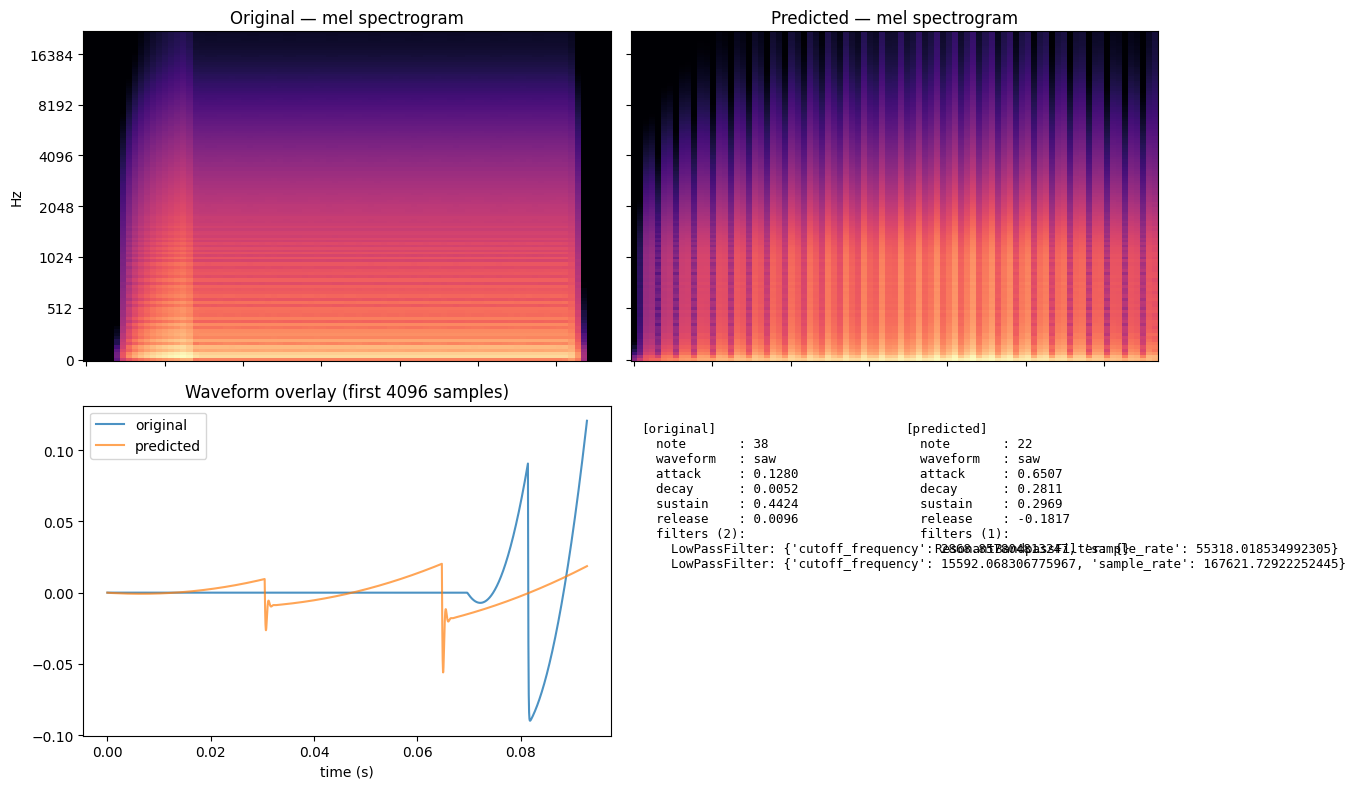

▶ Original audio


▶ Predicted audio


In [45]:
#  Run comparison 
cmp_spec   = random_ar_spec(vocab, max_filters=2)
cmp_mel    = render_mel(cmp_spec)
cmp_pred, cmp_tokens = generate_graph(model, cmp_mel, vocab, device=device)

print("Ground truth :", f"note={cmp_spec['note']}  "
      f"waveform={cmp_spec['source']['waveform']}  "
      f"filters={[f['type'] for f in cmp_spec['filters']]}")
print("Predicted     :", f"note={cmp_pred['note']}  "
      f"waveform={cmp_pred['source']['waveform']}  "
      f"filters={[f['type'] for f in cmp_pred['filters']]}")

orig_mono, pred_mono = compare_specs(cmp_spec, cmp_pred)

# Play both
print("▶ Original audio")
ipd.display(ipd.Audio(orig_mono, rate=44100))
print("▶ Predicted audio")
ipd.display(ipd.Audio(pred_mono, rate=44100))